In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from scipy import stats
from numpy.linalg import inv
import pandas as pd
import re

from MMA_QENS.core import Minimal_Model

print(MMA_QENS.core.__file__)

/Users/unikgyanu/MMA_QENS/MMA_QENS/core.py


In [7]:
# Reading QENS data from AMATERAS

def read_file(filename):
    regex = re.compile('[#,.!?:]')
    content = {}
    with open(filename) as file:
        fieldName, fieldValue = None,None
        for line in file:
            if line.startswith('#'):
                if fieldValue:
                    content.update({regex.sub('',fieldName): np.asarray(fieldValue).T})    
                fieldName = line
                fieldValue = []
            else:
                fieldValue.append([float(x) for x in line.split(' ') if x])
        content.update({regex.sub('',fieldName): np.asarray(fieldValue).T})
    return content

def convert(filename,hdf5=False):
    content = read_file(filename)
    Q = content[' yvalues\n'][0]
    omega = content[' xvalues\n'][0]
    G0 = np.resize(content['Group 0\n'],(2,len(content[' xvalues\n'][0])))
    G1 = np.resize(content['Group 1\n'],(2,len(content[' xvalues\n'][0])))
    G2 = np.resize(content['Group 2\n'],(2,len(content[' xvalues\n'][0])))
    G3 = np.resize(content['Group 3\n'],(2,len(content[' xvalues\n'][0])))
    G4 = np.resize(content['Group 4\n'],(2,len(content[' xvalues\n'][0])))
    G5 = np.resize(content['Group 5\n'],(2,len(content[' xvalues\n'][0])))
    G6 = np.resize(content['Group 6\n'],(2,len(content[' xvalues\n'][0])))
    G = np.array([G0[0],G1[0],G2[0],G3[0],G4[0],G5[0],G6[0]])
    eG = np.array([G0[1],G1[1],G2[1],G3[1],G4[1],G5[1],G6[1]])

    return np.array(Q), np.array(omega), np.array(G), np.array(eG)

# This function reads the DAVE file.

def read_dave_format(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()

    Nx = int(lines[1].strip())
    Ny = int(lines[3].strip())

    x_start = 5
    omega = np.array([float(lines[i].strip()) for i in range(x_start, x_start + Nx)])

    y_start = x_start + Nx + 1
    Q = np.array([float(lines[i].strip()) for i in range(y_start, y_start + Ny)])

    sqw = np.zeros((Ny, Nx))
    sqwerror = np.zeros((Ny, Nx))

    data_start = y_start + Ny
    idx = data_start

    for i in range(Ny):
        idx += 1
        for j in range(Nx):
            val, err = map(float, lines[idx].strip().split())
            sqw[i, j] = val
            sqwerror[i, j] = err
            idx += 1

    return np.array(omega), np.array(Q), np.array(sqw), np.array(sqwerror)

def unpad_sqw(omega, sqw, sqwerr, pad_value=0, err_pad_value=-1):
    omega_ranges, sqw_ranges, sqwerror_ranges = [], [], []
    
    NQ = sqw.shape[0]
    for i in range(NQ):
        mask = (sqw[i] != pad_value) & (sqwerr[i] != err_pad_value)
        omega_ranges.append(omega[mask])
        sqw_ranges.append(sqw[i][mask])
        sqwerror_ranges.append(sqwerr[i][mask])
    
    return omega_ranges, sqw_ranges, sqwerror_ranges


In [9]:

Q_a, omega_a, mt300_sqw_a, mt300_sqwerror_a = convert('Data/Mt300K_A.grp')
omega_a, mt300_sqw_a, mt300_sqwerror_a = unpad_sqw(omega_a, mt300_sqw_a, mt300_sqwerror_a)
mt300_sqw_a[3], mt300_sqwerror_a[3] = mt300_sqw_a[3][1:], mt300_sqwerror_a[3][1:]


Q_a, omega_a, ht300_sqw_a, ht300_sqwerror_a = convert('Data/Ht300K_A.grp')
omega_a, ht300_sqw_a, ht300_sqwerror_a = unpad_sqw(omega_a, ht300_sqw_a, ht300_sqwerror_a)
ht300_sqw_a[3], ht300_sqwerror_a[3] = ht300_sqw_a[3][1:], ht300_sqwerror_a[3][1:]


Q_a, omega_a, vana_sqw_a, vana_sqwerror_a = convert('Data/Vana3_A.grp')
omega_a, vana_sqw_a, vana_sqwerror_a = unpad_sqw(omega_a, vana_sqw_a, vana_sqwerror_a)


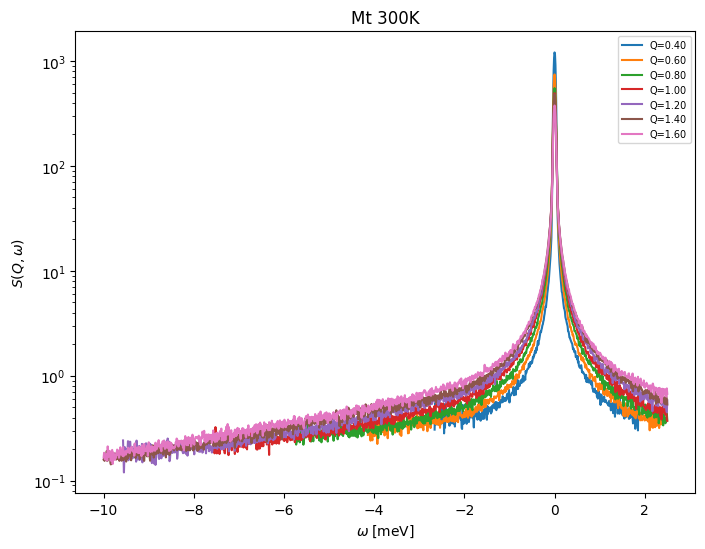

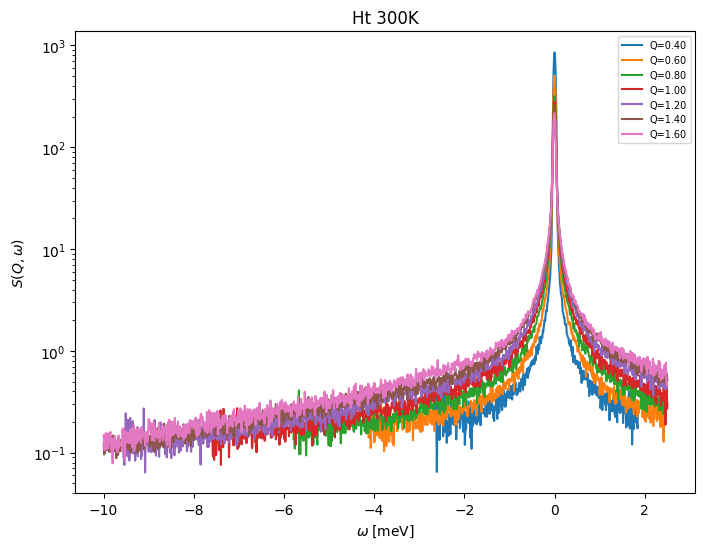

In [11]:
plt.figure(figsize=(8,6))
for i in range(len(Q_a)):
    plt.plot(omega_a[i], mt300_sqw_a[i], label=f"Q={Q_a[i]:.2f}")
plt.xlabel(r"$\omega \; [\mathrm{meV}]$")
plt.ylabel(r"$S(Q,\omega)$")
plt.title('Mt 300K')
plt.yscale('log')
#plt.xlim([-0.1,0.1])
plt.legend(fontsize=7)
plt.show()

plt.figure(figsize=(8,6))
for i in range(len(Q_a)):
    plt.plot(omega_a[i], ht300_sqw_a[i], label=f"Q={Q_a[i]:.2f}")
plt.xlabel(r"$\omega \; [\mathrm{meV}]$")
plt.ylabel(r"$S(Q,\omega)$")
plt.title('Ht 300K')
plt.yscale('log')
#plt.xlim([-0.1,0.1])
plt.legend(fontsize=7)
plt.show()


In [12]:
idx = 1
Temp = 300

In [13]:

Mt300K_A = Minimal_Model(mt300_sqw_a, vana_sqw_a, mt300_sqwerror_a, vana_sqwerror_a,Q_a,omega_a,'Mt 300 K (AMATERAS)',index = idx,T = Temp)


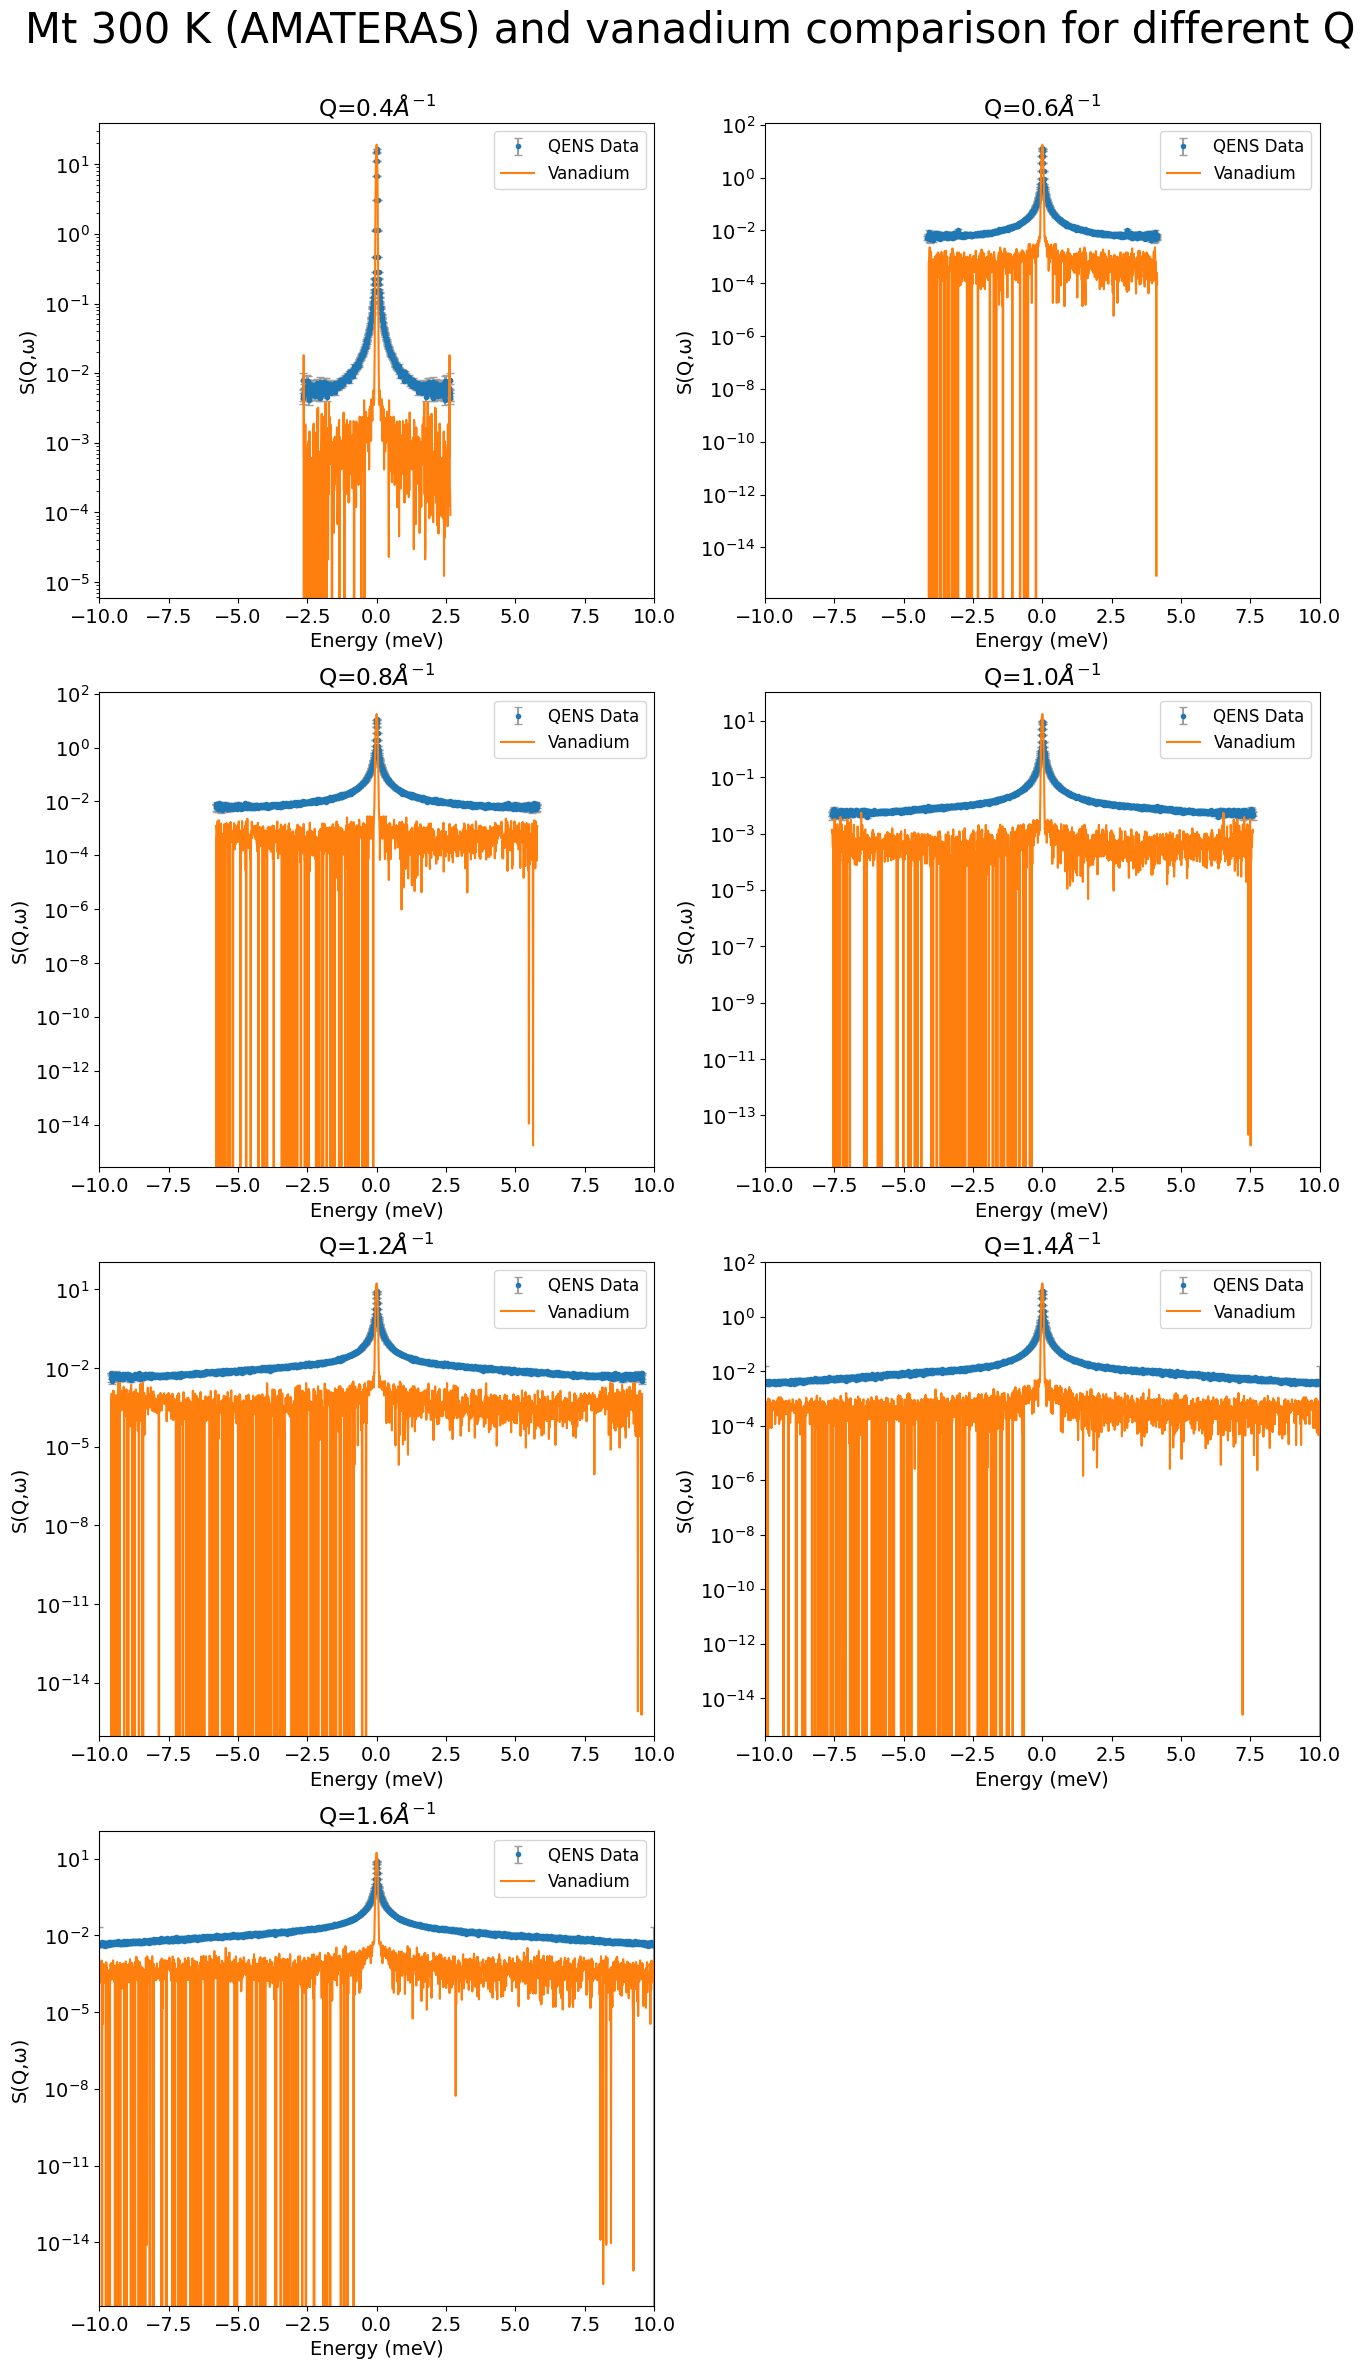

In [14]:
Mt300K_A.Sym_Norm(xlim = (-10,10),showplot = True)


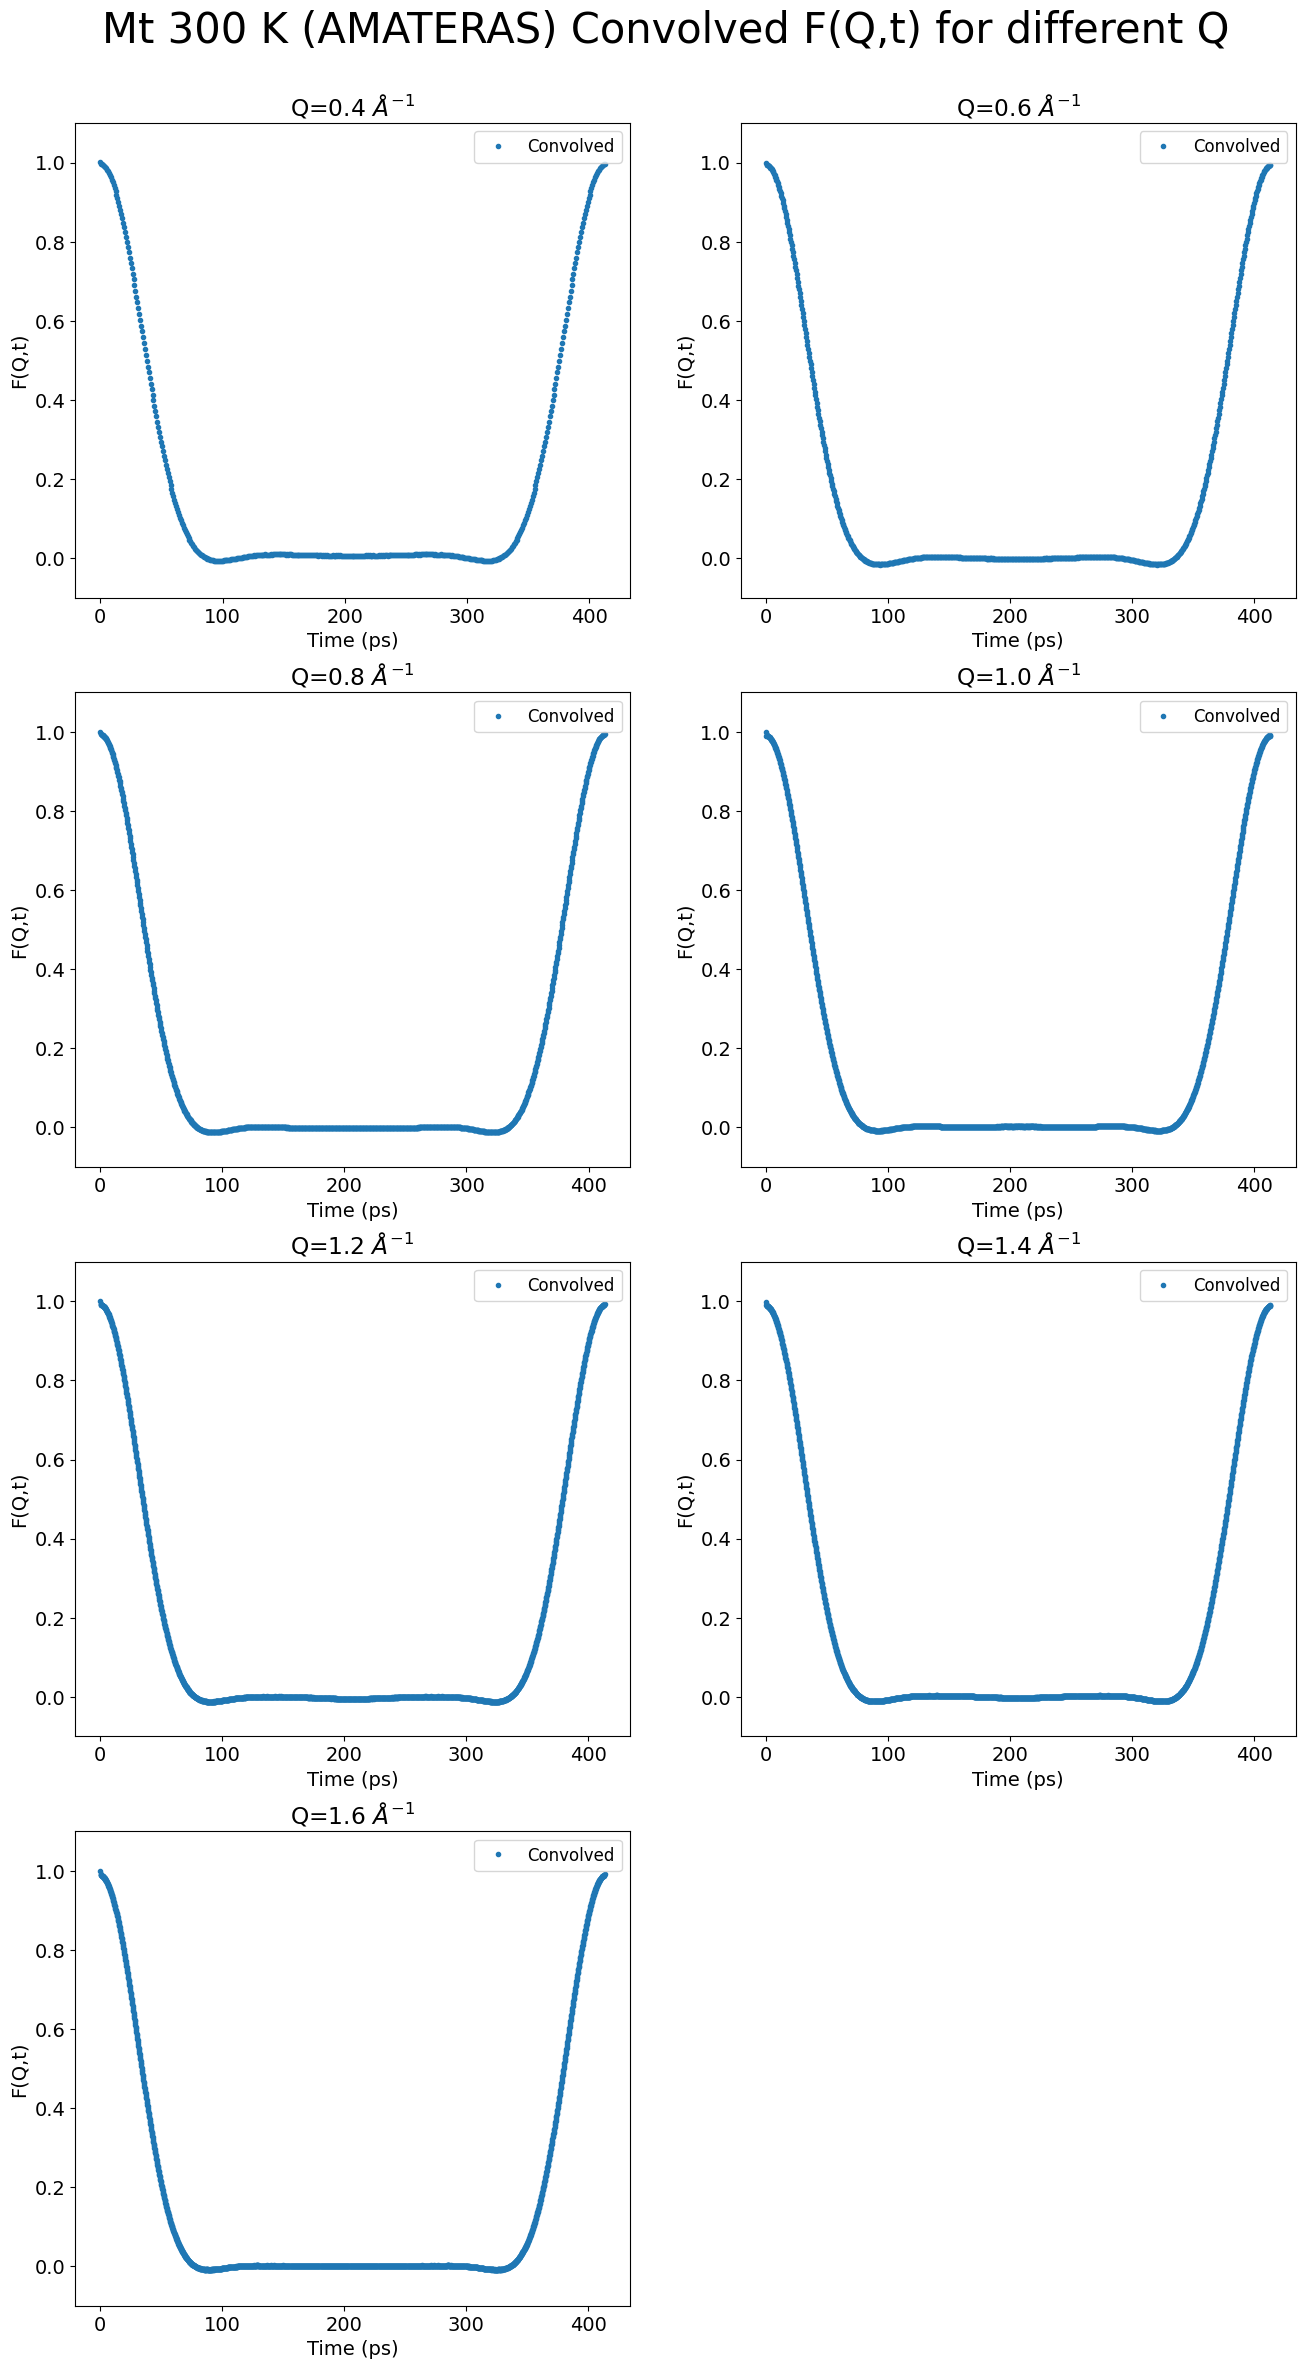

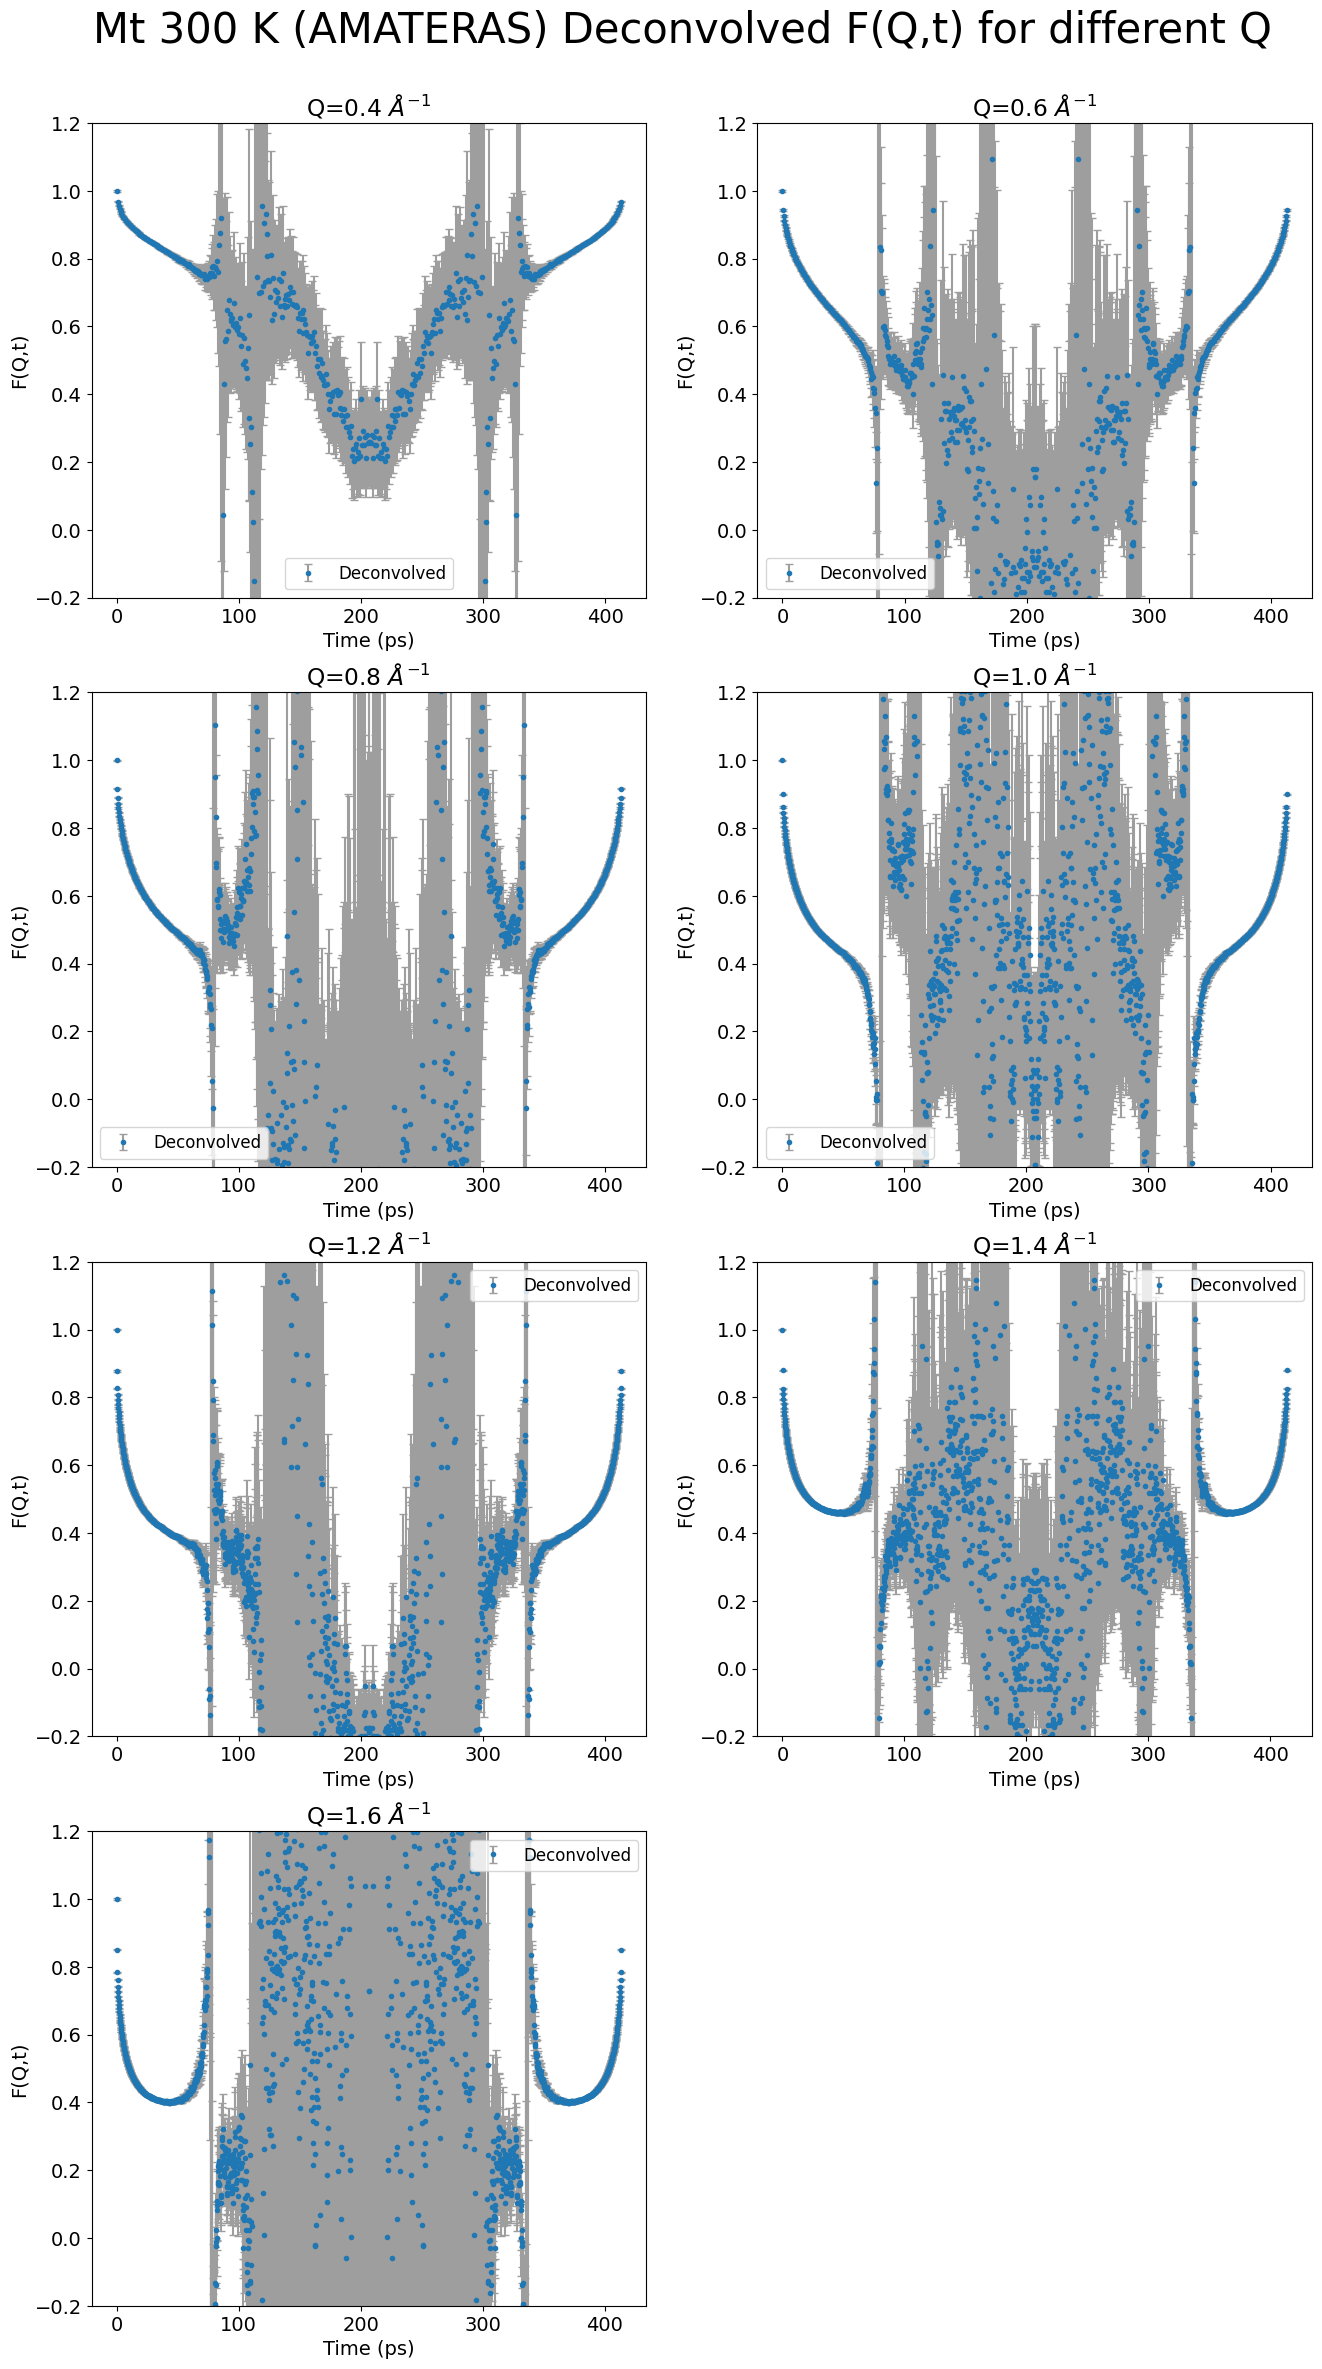

In [15]:
Mt300K_A.Deconvolve(showplot = True)


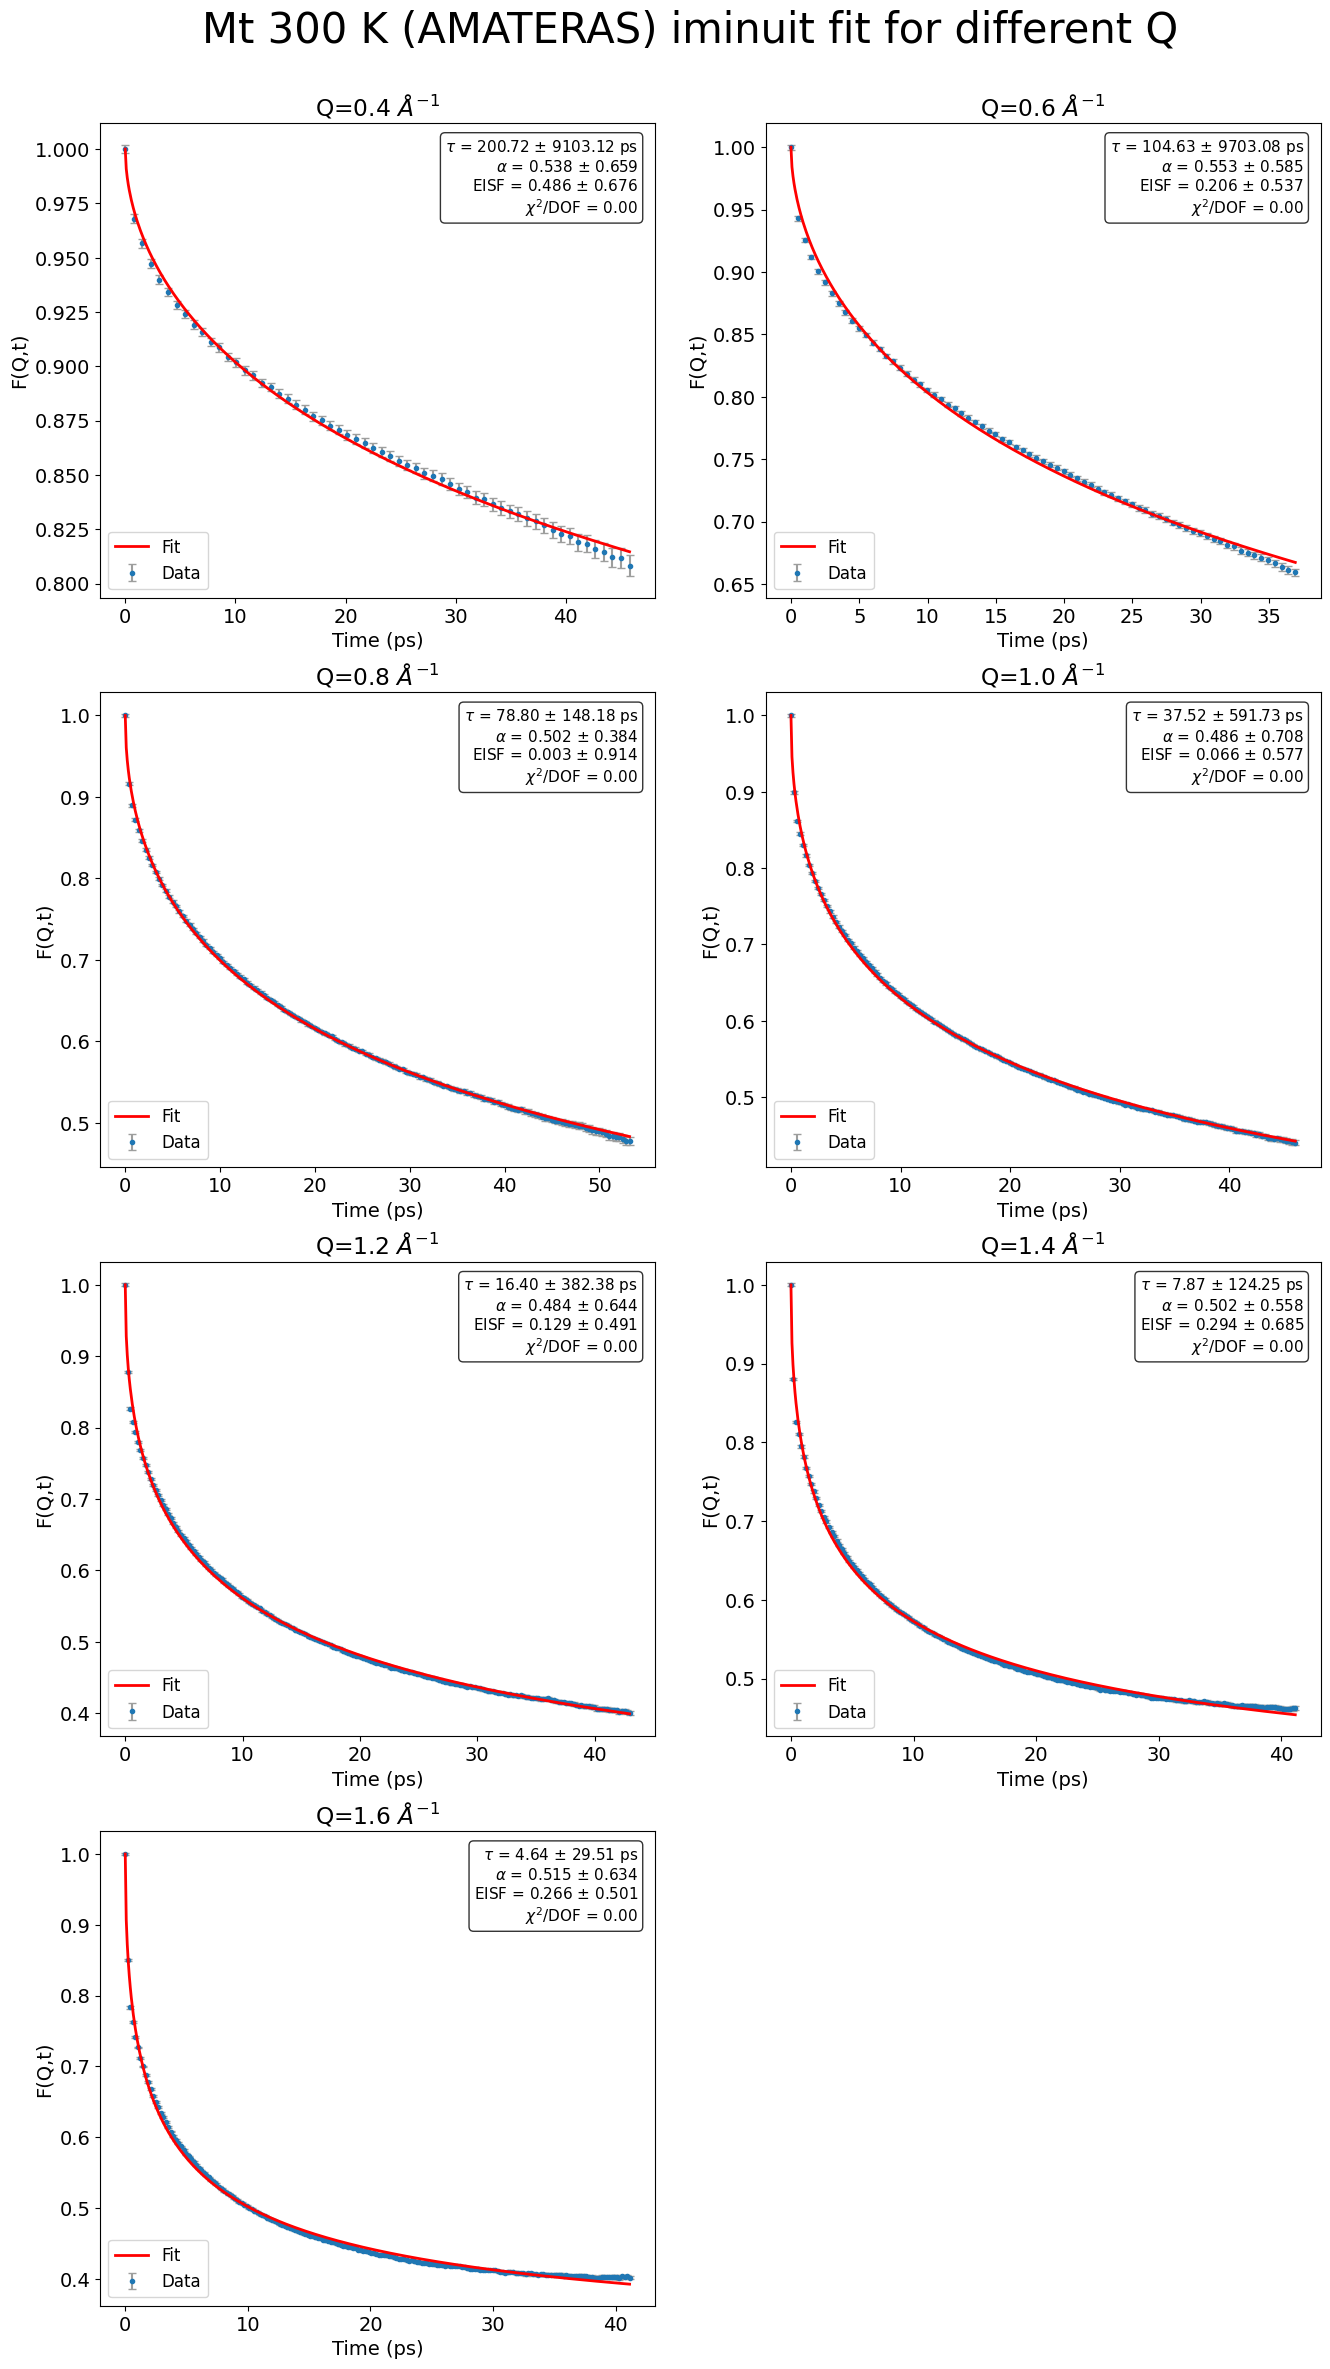

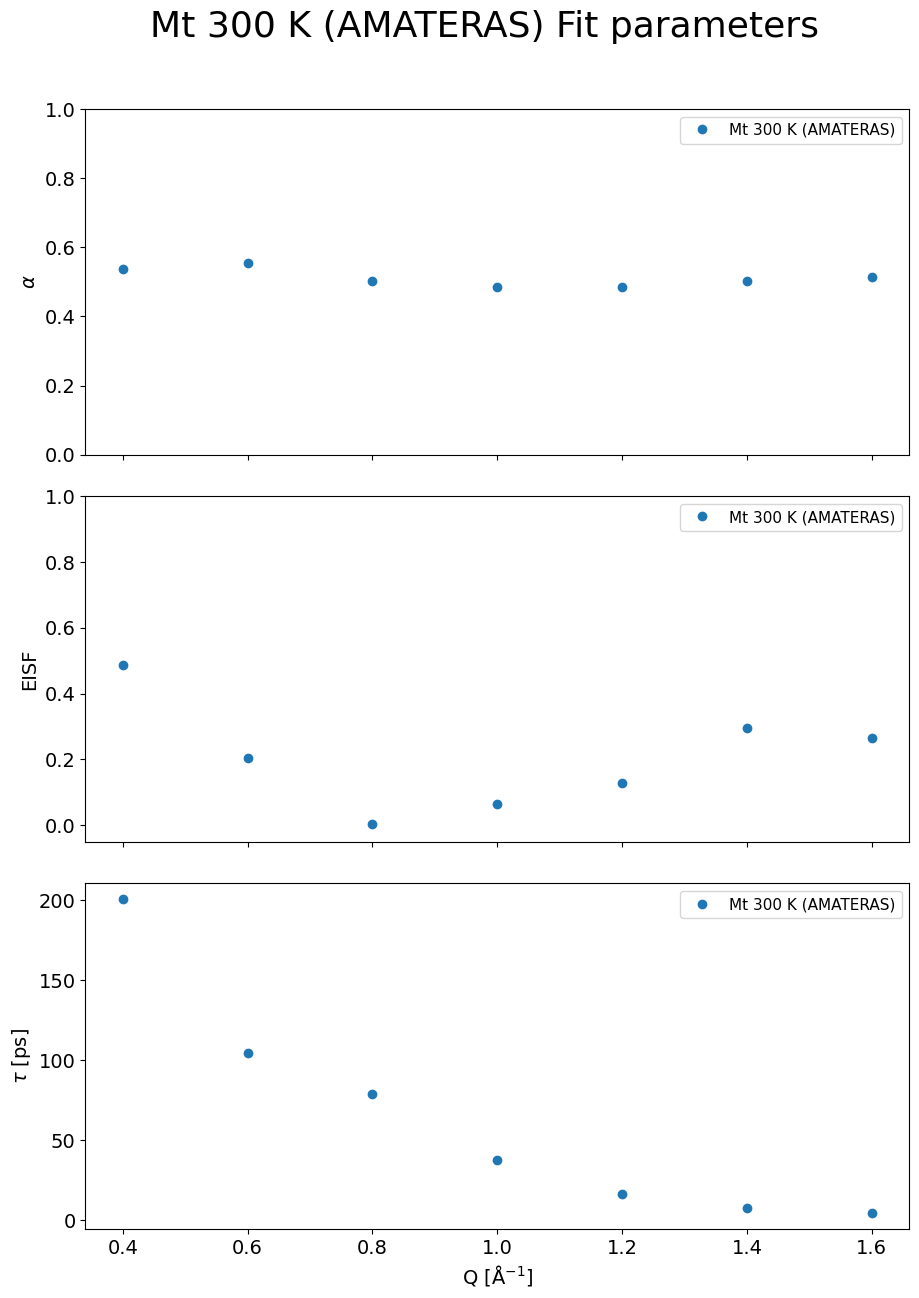

In [16]:
Mt300K_A.Fitting(N_cut = np.array([60,75,150,170,200,200,200]), p0 = [100,0.5,0.2], showplot =True)


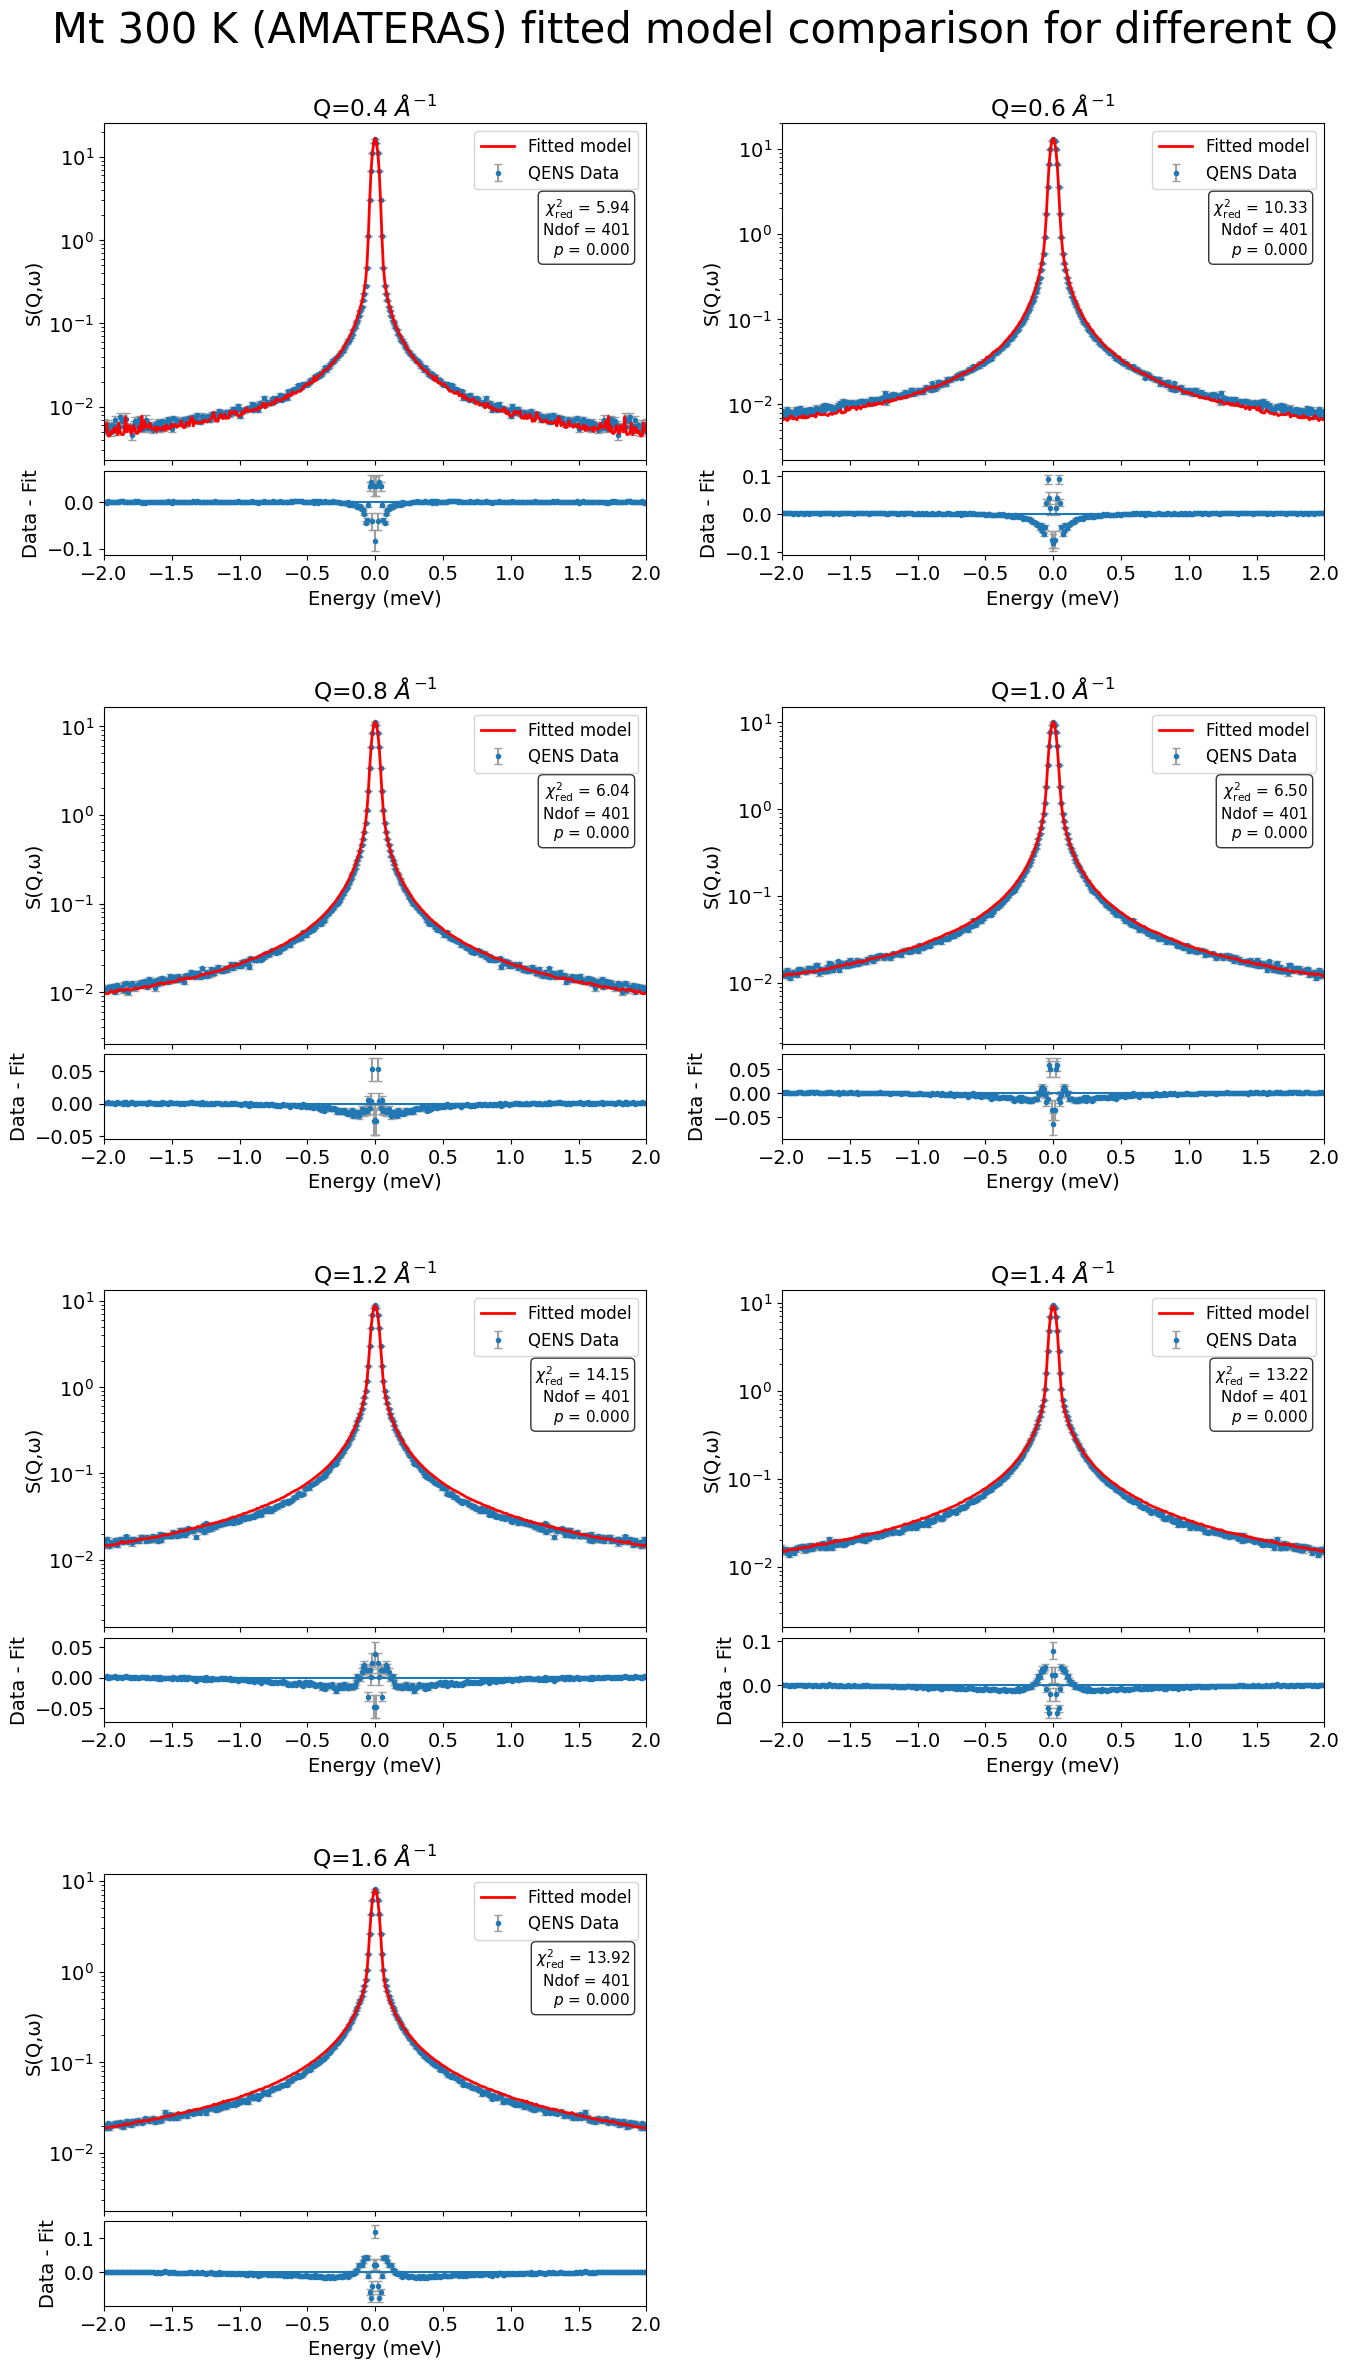

In [17]:
Mt300K_A.Resample(xlim = (-2,2), showplot =True)